# Detection against depth in the SARS-CoV-2 cohort

How many genes with alternative splicing, and how many junctions involved in
alternative splicing, are detected in the SARS-CoV-2 cohort as a function of
the number of uniquely mapped reads.

Input: `covid_summary.tsv`. Set `SUMMARY` below to wherever it lives. The file
is about 2 GB and is streamed line by line, which takes a few minutes.

In [1]:
import sys
from collections import defaultdict
from pathlib import Path
from statistics import mean, stdev

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymannkendall as mk

# Locate the top of the clone, so the notebook runs from any directory inside it.
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "asdepth").is_dir()), None)
if ROOT is None:
    raise RuntimeError("run this from inside a clone of RNA-Seq_Depth_for_AS")
sys.path.insert(0, str(ROOT))
from asdepth import SINGLE_COLOR, count_per_sample, thousands

RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

SUMMARY = Path("covid_summary.tsv")

DEPTHS = ["60M", "70M", "80M", "90M", "100M", "110M", "120M", "130M", "140M", "150M"]

# Expression categories, as half-open TPM intervals.
CATEGORIES = [(0, 0.1), (0.1, 0.5), (0.5, 1), (1, 10), (10, float("inf"))]

# Total number of genes / junctions per expression category in each cohort.
# These come from the featureCounts TPM table and the regtools junction list
# rather than from the MAJIQ summary, so they are kept as a small constant
# table. The increment table below expresses new detections as a fraction
# of them.
TOTALS = (
    pd.read_csv(ROOT / "data" / "expression_category_totals.tsv", sep="\t")
    .query("dataset == 'sars_cov_2'")
    .set_index(["kind", "category"])["total"]
)

def label(low, high):
    return f"{low}<=TPM<{'inf' if high == float('inf') else high}"


def category_key(low, high):
    """Row label used in data/expression_category_totals.tsv."""
    return f"{low:g}-{'inf' if high == float('inf') else f'{high:g}'}"

## Counting

In [2]:
per_sample, depth_of_sample = count_per_sample(SUMMARY, CATEGORIES)

print(f"{len(depth_of_sample)} samples")
print(pd.Series(depth_of_sample).value_counts().reindex(DEPTHS).to_string())

97 samples
60M      4
70M     10
80M     23
90M     18
100M     8
110M     4
120M    15
130M     7
140M     6
150M     2


In [3]:
def summarise(counts):
    """Mean and standard deviation of the per-sample counts at each depth."""
    by_depth = defaultdict(list)
    for sample, value in counts.items():
        by_depth[depth_of_sample[sample]].append(value)

    averages, deviations = {}, {}
    for depth, values in by_depth.items():
        values = sorted(set(values))
        averages[depth] = mean(values)
        deviations[depth] = stdev(values) if len(values) > 1 else 0.0
    return averages, deviations


summary = {
    (category, kind): summarise(per_sample[category][kind])
    for category in CATEGORIES
    for kind in ("genes", "junctions")
}

## Mann-Kendall trend test

The magnitude of the monotonic trend in each panel.

In [4]:
trends = {}
for key, (averages, _) in summary.items():
    trends[key] = mk.original_test([averages[depth] for depth in DEPTHS])

pd.DataFrame(
    [
        {
            "category": f"{low} <= TPM < {high}",
            "kind": kind,
            "slope": trends[(low, high), kind].slope,
            "p": trends[(low, high), kind].p,
            "trend": trends[(low, high), kind].trend,
        }
        for (low, high) in CATEGORIES
        for kind in ("genes", "junctions")
    ]
)

,category,kind,slope,p,trend
0,0 <= TPM < 0.1,genes,60.812500,0.000347,increasing
1,0 <= TPM < 0.1,junctions,482.657407,0.000172,increasing
2,0.1 <= TPM < 0.5,genes,41.926708,0.000677,increasing
3,0.1 <= TPM < 0.5,junctions,312.189614,0.000172,increasing
4,0.5 <= TPM < 1,genes,27.583333,0.000677,increasing
5,0.5 <= TPM < 1,junctions,268.733696,0.000677,increasing
6,1 <= TPM < 10,genes,78.387500,0.001282,increasing
7,1 <= TPM < 10,junctions,1763.722222,0.000677,increasing
8,10 <= TPM < inf,genes,17.069444,0.000677,increasing
9,10 <= TPM < inf,junctions,1252.270833,0.002358,increasing


## The bar plots

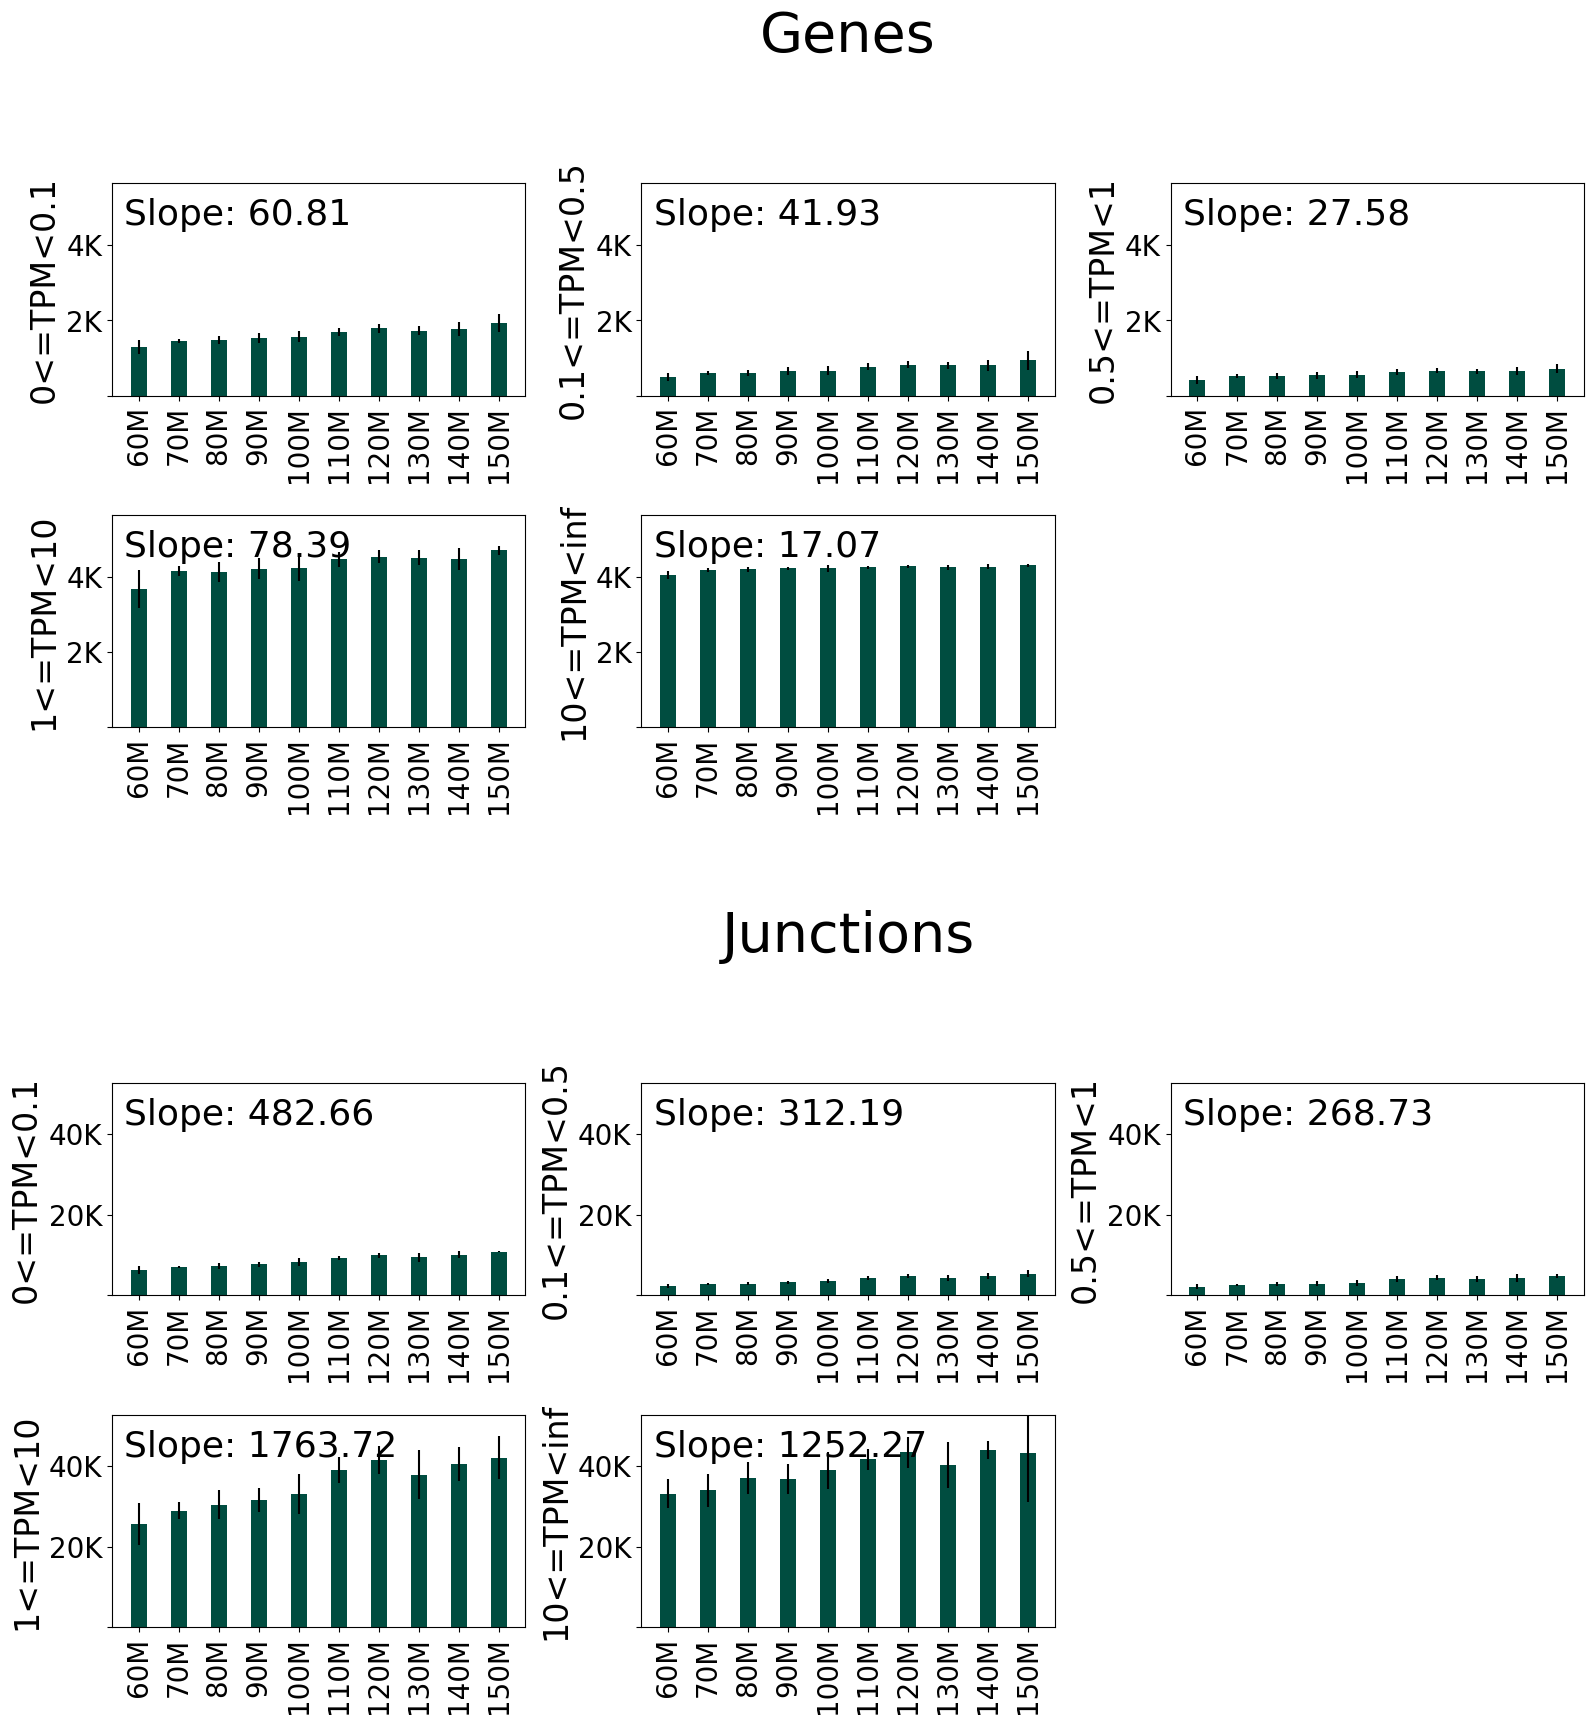

In [5]:
figure = plt.figure(figsize=(19, 21))
# Two blocks of five panels; a thin row above each block carries its heading.
grid = figure.add_gridspec(
    6, 3, height_ratios=[0.25, 1, 1, 0.55, 1, 1], hspace=0.7, wspace=0.28
)
POSITIONS = [(1, 0), (1, 1), (1, 2), (2, 0), (2, 1)]

for offset, kind in ((0, "genes"), (3, "junctions")):
    heading = figure.add_subplot(grid[offset, :])
    heading.axis("off")
    heading.text(0.5, 0.0, kind.capitalize(), ha="center", va="bottom", fontsize=40)

    ceiling = 1.2 * max(
        max(summary[category, kind][0].values()) for category in CATEGORIES
    )
    for (low, high), (row, column) in zip(CATEGORIES, POSITIONS):
        axes = figure.add_subplot(grid[row + offset, column])
        averages, deviations = summary[(low, high), kind]
        axes.bar(
            np.arange(len(DEPTHS)),
            [averages[depth] for depth in DEPTHS],
            yerr=[deviations[depth] for depth in DEPTHS],
            width=0.4,
            color=SINGLE_COLOR,
        )
        axes.set_xticks(np.arange(len(DEPTHS)))
        axes.set_xticklabels(DEPTHS, rotation=90, fontsize=20)
        axes.tick_params(axis="y", labelsize=20)
        axes.yaxis.set_major_formatter(plt.FuncFormatter(thousands))
        axes.set_ylabel(label(low, high), fontsize=24)
        axes.set_ylim(0, ceiling)

        result = trends[(low, high), kind]
        if result.p < 0.05:
            axes.text(0.03, 0.93, f"Slope: {result.slope:.2f}",
                      transform=axes.transAxes, fontsize=26, va="top")

figure.savefig(RESULTS / "Figure_1.png", dpi=300, bbox_inches="tight")
plt.show()

## New detections between consecutive depths

New detections between consecutive depths, in absolute numbers and as a
percentage of the cohort total for that expression category.

In [6]:
rows = []
for kind in ("genes", "junctions"):
    for low, high in CATEGORIES:
        averages = summary[(low, high), kind][0]
        total = TOTALS[kind, category_key(low, high)]
        series = [averages[depth] for depth in DEPTHS]
        row = {
            "kind": kind,
            "category": label(low, high),
            "at 60M": series[0],
            "at 60M, %": series[0] / total * 100,
            "at 150M": series[-1],
            "at 150M, %": series[-1] / total * 100,
        }
        for start, end, gained in zip(DEPTHS, DEPTHS[1:], np.diff(series)):
            row[f"{start}->{end}"] = gained
            row[f"{start}->{end}, %"] = gained / total * 100
        rows.append(row)

table2 = pd.DataFrame(rows).set_index(["kind", "category"])
table2.round(2).to_csv(RESULTS / "Table_2.tsv", sep="\t")
table2.filter(regex=r"%$").round(2)

at 60M, %  at 150M, %  60M->70M, %  70M->80M, %  \
kind      category                                                        
genes     0<=TPM<0.1        20.93       31.43         2.62         0.32   
          0.1<=TPM<0.5      11.82       22.16         2.50        -0.35   
          0.5<=TPM<1        20.74       35.64         5.22        -0.39   
          1<=TPM<10         50.62       64.88         6.53        -0.35   
          10<=TPM<inf       79.19       84.23         2.64         0.33   
junctions 0<=TPM<0.1        25.85       44.57         2.95         1.43   
          0.1<=TPM<0.5       7.50       16.83         1.34         0.28   
          0.5<=TPM<1        10.14       21.70         2.04         0.42   
          1<=TPM<10         17.71       29.05         2.26         1.03   
          10<=TPM<inf       21.38       27.78         0.50         1.99   

                        80M->90M, %  90M->100M, %  100M->110M, %  \
kind      category                                                 
genes     0<=TPM<0.1           1.03          0.41           2.16   
          0.1<=TPM<0.5         1.29          0.46           2.55   
          0.5<=TPM<1           1.47          0.54           3.88   
          1<=TPM<10            1.34          0.38           2.95   
          10<=TPM<inf          0.38          0.11           0.56   
junctions 0<=TPM<0.1           1.58          2.17           4.18   
          0.1<=TPM<0.5         0.95          0.85           2.45   
          0.5<=TPM<1           0.85          0.80           4.35   
          1<=TPM<10            0.72          1.09           4.08   
          10<=TPM<inf         -0.21          1.42           1.73   

                        110M->120M, %  120M->130M, %  130M->140M, %  \
kind      category                                                    
genes     0<=TPM<0.1             1.48          -0.93           0.71   
          0.1<=TPM<0.5           1.14          -0.46           0.16   
          0.5<=TPM<1             1.28          -0.67           0.16   
          1<=TPM<10              1.06          -0.43          -0.42   
          10<=TPM<inf            0.50          -0.59           0.38   
junctions 0<=TPM<0.1             2.77          -2.15           2.82   
          0.1<=TPM<0.5           1.43          -1.21           1.37   
          0.5<=TPM<1             1.69          -1.92           1.43   
          1<=TPM<10              1.66          -2.47           1.89   
          10<=TPM<inf            1.14          -1.95           2.32   

                        140M->150M, %  
kind      category                     
genes     0<=TPM<0.1             2.69  
          0.1<=TPM<0.5           3.05  
          0.5<=TPM<1             3.41  
          1<=TPM<10              3.20  
          10<=TPM<inf            0.73  
junctions 0<=TPM<0.1             2.95  
          0.1<=TPM<0.5           1.88  
          0.5<=TPM<1             1.90  
          1<=TPM<10              1.07  
          10<=TPM<inf           -0.54